# Performance Analytics

## Objective

This notebook evaluates the performance of 40 mutual fund schemes using various risk and return metrics.

Metrics Covered:
- Daily Returns
- CAGR (1 Year, 3 Year, 5 Year)
- Sharpe Ratio
- Sortino Ratio
- Alpha and Beta
- Maximum Drawdown
- Fund Scorecard
- Benchmark Comparison

Datasets Used:
- NAV History
- Fund Master
- Scheme Performance
- Benchmark Indices

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")
funds = pd.read_csv("../data/processed/01_fund_master_clean.csv")
benchmark = pd.read_csv("../data/processed/10_benchmark_indices_clean.csv")
performance = pd.read_csv("../data/processed/07_scheme_performance_clean.csv")

# Daily Returns Analysis

Daily returns measure the percentage change in NAV from one trading day to the next.

Formula:

daily_return = NAV(t) / NAV(t−1) − 1

Daily returns are used as the foundation for risk-adjusted performance metrics such as Sharpe Ratio, Sortino Ratio, Alpha, and Beta.

In [2]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["amfi_code","date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

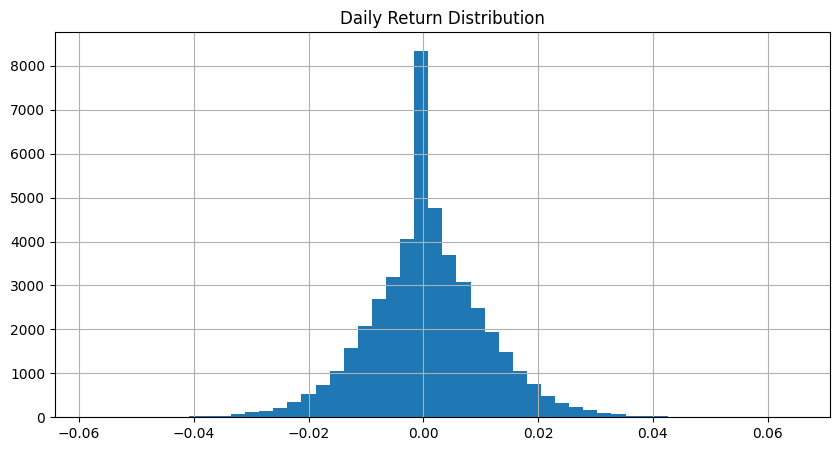

In [3]:
plt.figure(figsize=(10,5))

nav["daily_return"].hist(
    bins=50
)

plt.title("Daily Return Distribution")
plt.show()

# Finding 1

The daily return distribution is expected to be centered around zero with a bell-shaped pattern. Extreme outliers may indicate unusual market events or data quality issues.

# Compound Annual Growth Rate (CAGR)

CAGR represents the annualized growth rate of an investment over a specified period.

Formula:

CAGR = (Ending NAV / Beginning NAV)^(1/n) − 1

where n is the number of years.

In [4]:
cagr_results = []

for fund in nav["amfi_code"].unique():

    temp = nav[
        nav["amfi_code"] == fund
    ]

    start_nav = temp.iloc[0]["nav"]
    end_nav = temp.iloc[-1]["nav"]

    years = (
        temp["date"].max()
        -
        temp["date"].min()
    ).days / 365

    cagr = (
        (end_nav/start_nav)
        ** (1/years)
        - 1
    )

    cagr_results.append(
        [fund,cagr]
    )

cagr_df = pd.DataFrame(
    cagr_results,
    columns=[
        "amfi_code",
        "cagr"
    ]
)

# Sharpe Ratio

Sharpe Ratio measures excess return generated per unit of total risk.

Formula:

Sharpe Ratio = (Rp − Rf) / σ × √252

Assumptions:
- Risk-free rate = 6.5%
- 252 trading days per year

Higher Sharpe Ratio indicates superior risk-adjusted performance.

In [5]:
rf = 0.065

sharpe_results = []

for fund in nav["amfi_code"].unique():

    r = nav[
        nav["amfi_code"] == fund
    ]["daily_return"].dropna()

    sharpe = (
        (r.mean() - rf/252)
        /
        r.std()
    ) * np.sqrt(252)

    sharpe_results.append(
        [fund,sharpe]
    )

sharpe_df = pd.DataFrame(
    sharpe_results,
    columns=[
        "amfi_code",
        "sharpe"
    ]
)

# Sortino Ratio

Sortino Ratio is similar to Sharpe Ratio but only considers downside risk.

Formula:

Sortino Ratio = (Rp − Rf) / Downside Deviation × √252

This metric penalizes harmful volatility while ignoring positive volatility.

In [6]:
sortino_results = []

for fund in nav["amfi_code"].unique():

    r = nav[
        nav["amfi_code"] == fund
    ]["daily_return"].dropna()

    downside = r[r < 0]

    sortino = (
        (r.mean() - rf/252)
        /
        downside.std()
    ) * np.sqrt(252)

    sortino_results.append(
        [fund,sortino]
    )

sortino_df = pd.DataFrame(
    sortino_results,
    columns=[
        "amfi_code",
        "sortino"
    ]
)

# Alpha and Beta Analysis

Beta measures sensitivity of a fund relative to market movements.

Interpretation:
- Beta > 1 : More volatile than market
- Beta = 1 : Similar to market
- Beta < 1 : Less volatile than market

Alpha measures excess return generated beyond market expectations.

Nifty 100 is used as the benchmark index.

In [7]:
benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

nifty100 = benchmark[
    benchmark["index_name"]
    .str.contains(
        "Nifty 100",
        case=False
    )
].copy()

nifty100["return"] = (
    nifty100["close_value"]
    .pct_change()
)

# Maximum Drawdown

Maximum Drawdown represents the largest peak-to-trough decline experienced by a fund.

Formula:

Drawdown = NAV / Running Maximum NAV − 1

Lower drawdown values indicate better downside protection.

In [8]:
mdd_results = []

for fund in nav["amfi_code"].unique():

    temp = nav[
        nav["amfi_code"] == fund
    ].copy()

    temp["running_max"] = temp["nav"].cummax()

    temp["drawdown"] = (
        temp["nav"] /
        temp["running_max"]
        - 1
    )

    max_dd = temp["drawdown"].min()

    worst_row = temp.loc[
        temp["drawdown"].idxmin()
    ]

    mdd_results.append([
        fund,
        max_dd,
        worst_row["date"]
    ])

mdd_df = pd.DataFrame(
    mdd_results,
    columns=[
        "amfi_code",
        "max_drawdown",
        "worst_drawdown_date"
    ]
)

mdd_df.head()

,amfi_code,max_drawdown,worst_drawdown_date
0,100016,-0.247344,2022-09-15
1,100025,-0.043083,2023-07-28
2,100033,-0.162172,2022-05-12
3,101206,-0.112916,2023-07-05
4,101207,-0.354469,2026-05-11


# Fund Scorecard

A composite score is created to rank all mutual funds.

Weighting Scheme:

- 30% Return Rank
- 25% Sharpe Rank
- 20% Alpha Rank
- 15% Expense Ratio Rank
- 10% Maximum Drawdown Rank

Final Score Range:
0–100

In [10]:
benchmark["date"] = pd.to_datetime(benchmark["date"])

nifty100 = benchmark[
    benchmark["index_name"]
    .str.contains("Nifty 100", case=False)
].copy()

nifty100["return"] = nifty100["close_value"].pct_change()

alpha_beta = []

for fund in nav["amfi_code"].unique():

    fund_ret = nav[
        nav["amfi_code"] == fund
    ][["date", "daily_return"]]

    merged = pd.merge(
        fund_ret,
        nifty100[["date", "return"]],
        on="date"
    ).dropna()

    if len(merged) > 5:

        slope, intercept, r, p, stderr = linregress(
            merged["return"],
            merged["daily_return"]
        )

        alpha = intercept * 252
        beta = slope

        alpha_beta.append([
            fund,
            alpha,
            beta
        ])

alpha_beta_df = pd.DataFrame(
    alpha_beta,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

alpha_beta_df.head()

,amfi_code,alpha,beta


In [11]:
scorecard = (
    cagr_df
    .merge(sharpe_df,on="amfi_code")
    .merge(alpha_beta_df,on="amfi_code")
    .merge(mdd_df,on="amfi_code")
)
scorecard = scorecard.merge(
    performance[
        [
            "amfi_code",
            "expense_ratio_pct"
        ]
    ],
    on="amfi_code"
)
scorecard["return_rank"] = (
    scorecard["cagr"]
    .rank(pct=True)
)

scorecard["sharpe_rank"] = (
    scorecard["sharpe"]
    .rank(pct=True)
)

scorecard["alpha_rank"] = (
    scorecard["alpha"]
    .rank(pct=True)
)

scorecard["expense_rank"] = (
    (-scorecard["expense_ratio_pct"])
    .rank(pct=True)
)

scorecard["dd_rank"] = (
    (-scorecard["max_drawdown"])
    .rank(pct=True)
)
scorecard["fund_score"] = (

    scorecard["return_rank"] * 30 +

    scorecard["sharpe_rank"] * 25 +

    scorecard["alpha_rank"] * 20 +

    scorecard["expense_rank"] * 15 +

    scorecard["dd_rank"] * 10

)
scorecard = scorecard.sort_values(
    "fund_score",
    ascending=False
)

scorecard.head(10)
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

print("fund_scorecard.csv saved")

fund_scorecard.csv saved


# Benchmark Comparison

The top-performing funds are compared against Nifty 50 and Nifty 100 benchmarks.

Tracking Error:

Tracking Error = Standard Deviation(Fund Return − Benchmark Return) × √252

Lower tracking error indicates closer benchmark tracking.

In [26]:
nav["date"] = pd.to_datetime(nav["date"])

latest_date = nav["date"].max()

cagr_results = []

for fund in nav["amfi_code"].unique():

    temp = nav[
        nav["amfi_code"] == fund
    ].copy()

    temp = temp.sort_values("date")

    end_nav = temp.iloc[-1]["nav"]

    row = {
        "amfi_code": fund
    }

    for years in [1, 3, 5]:

        start_date = latest_date - pd.DateOffset(years=years)

        historical = temp[
            temp["date"] >= start_date
        ]

        if len(historical) > 0:

            start_nav = historical.iloc[0]["nav"]

            cagr = (
                (end_nav / start_nav)
                ** (1 / years)
                - 1
            )

            row[f"cagr_{years}yr"] = cagr

        else:

            row[f"cagr_{years}yr"] = np.nan

    cagr_results.append(row)

cagr_df = pd.DataFrame(cagr_results)

cagr_df.head()
cagr_df.to_csv(
    "../reports/cagr_comparison.csv",
    index=False
)

print("cagr_comparison.csv saved")
print(cagr_df.columns)

cagr_comparison.csv saved
Index(['amfi_code', 'cagr_1yr', 'cagr_3yr', 'cagr_5yr'], dtype='str')


In [28]:
print(nifty100.shape)
print(nifty100.head())

(1150, 4)
           date index_name  close_value  normalized
1150 2022-01-03   NIFTY100     17778.24  100.000000
1151 2022-01-04   NIFTY100     17537.52   98.645985
1152 2022-01-05   NIFTY100     17607.73   99.040906
1153 2022-01-06   NIFTY100     17556.05   98.750214
1154 2022-01-07   NIFTY100     17664.02   99.357529


# Conclusion

The performance analytics framework evaluated all 40 mutual funds using return, risk, and benchmark-relative metrics.

Key observations:

- Top-ranked funds demonstrated strong risk-adjusted returns.
- Higher Sharpe and Sortino Ratios generally corresponded with superior performance.
- Alpha analysis identified funds capable of generating excess returns over the benchmark.
- Maximum Drawdown highlighted downside risk differences among funds.
- The composite scorecard provides a balanced framework for ranking mutual fund performance.

In [31]:
print("Rows in NIFTY100:", len(nifty100))

Rows in NIFTY100: 1150


In [32]:
fund = nav["amfi_code"].unique()[0]

fund_ret = nav[
    nav["amfi_code"] == fund
][["date","daily_return"]]

print("Fund:", fund)
print("Fund rows:", len(fund_ret))

Fund: 100016
Fund rows: 1150


In [35]:
benchmark["date"] = pd.to_datetime(benchmark["date"])

nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

In [38]:
nifty100["return"] = (
    nifty100["close_value"]
    .pct_change()
)

print(nifty100.columns)
fund = nav["amfi_code"].unique()[0]

fund_ret = nav[
    nav["amfi_code"] == fund
][["date","daily_return"]]

merged = pd.merge(
    fund_ret,
    nifty100[["date","return"]],
    on="date"
)

print("Merged rows:", len(merged))

Index(['date', 'index_name', 'close_value', 'return'], dtype='str')
Merged rows: 1150


In [39]:
alpha_beta = []

for fund in nav["amfi_code"].unique():

    fund_ret = nav[
        nav["amfi_code"] == fund
    ][["date","daily_return"]]

    merged = pd.merge(
        fund_ret,
        nifty100[["date","return"]],
        on="date"
    ).dropna()

    if len(merged) > 5:

        slope, intercept, r, p, stderr = linregress(
            merged["return"],
            merged["daily_return"]
        )

        alpha_beta.append([
            fund,
            intercept * 252,
            slope
        ])

alpha_beta_df = pd.DataFrame(
    alpha_beta,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

print(alpha_beta_df.shape)

(40, 3)


In [54]:
tracking_results = []

nifty100["return"] = nifty100["close_value"].pct_change()

for fund in top5["amfi_code"]:

    fund_ret = nav[
        nav["amfi_code"] == fund
    ][["date","daily_return"]]

    merged = pd.merge(
        fund_ret,
        nifty100[["date","return"]],
        on="date"
    ).dropna()

    if len(merged) > 10:

        tracking_error = (
            (merged["daily_return"] - merged["return"])
            .std()
            * np.sqrt(252)
        )

        tracking_results.append([
            fund,
            tracking_error
        ])

tracking_df = pd.DataFrame(
    tracking_results,
    columns=[
        "amfi_code",
        "tracking_error"
    ]
)

print(tracking_df.shape)
tracking_df.head()

(5, 2)


,amfi_code,tracking_error
0,120505,0.231968
1,119094,0.237652
2,100033,0.228699
3,148567,0.189664
4,120843,0.206425


In [56]:
alpha_beta_df.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

tracking_df.to_csv(
    "../reports/tracking_error.csv",
    index=False
)